In [1]:
import logging
logging.basicConfig(
    level=logging.INFO,
    format='%(name)s — %(levelname)s — %(message)s',
)

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import polars as pl
import pandas as pd
import tifffile as tiff
from tifffile import imwrite, imread
from copy import deepcopy
import os
import time
from copy import copy
from skimage.filters import gaussian
from scipy.spatial.distance import cdist
import xarray as xr

import sys

sys.path.append("../../..")
from src import IOFunctions

IO = IOFunctions.IO_Functions()

from src import Multicolour_Simulation_Functions

MSF = Multicolour_Simulation_Functions.MultiC_Sim_Funcs()

from src import PSFFunctions

PSF = PSFFunctions.PSF_Functions()

from src import PlottingBase

plotter = PlottingBase.PublicationPlotter(dark_background=False)

from src import ImageAnalysisFunctions

I_AF = ImageAnalysisFunctions.Image_Analysis_Functions()

from src import sCMOSFunctions

sCMOS = sCMOSFunctions.sCMOS_Functions()

from src import SpectralFunctions

S_F = SpectralFunctions.Spectral_Funcs()

from src import MaskFunctions

M_F = MaskFunctions.Mask_Functions()


import types

smoothing_function = types.SimpleNamespace()
smoothing_function.args = {"sigma": 1.5}
smoothing_function.extent = 1.5
smoothing_function.smoothing_function = sCMOS.gaussian_filter_stack
smoothing_function.data_arg = "image"

numexpr.utils — INFO — Note: NumExpr detected 32 cores but "NUMEXPR_MAX_THREADS" not set, so enforcing safe limit of 16.
numexpr.utils — INFO — NumExpr defaulting to 16 threads.
Constants — INFO — Logging to file: /home/jsb92/Documents/pyS3M/notebooks/figures/SI/../../../logs/Constants_20260702_215129.log


## Spectral Filter Patterns

Comparison of six pixel spectral sensitivity designs, all using a 2×2 spatial mosaic, simulated against ATTO 488, ATTO 565, and ATTO 647N:

| Name | Pixel types | Description |
|------|-------------|-------------|
| **Bayer** | R, G, G, B | Standard RGGB reference |
| **CYYM** | C, Y, Y, M | Cyan–Yellow–Yellow–Magenta |
| **RGBE** | R, G, B, E | Standard RGB + narrow Emerald (~520 nm) |
| **RGBW** | R, G, B, W | Standard RGB + panchromatic White pixel |
| **SinCos** | sin₁, cos₁, sin₂, cos₂ | 1st and 2nd harmonic phasor spectra across visible range |
| **NIR** | R, G, B, N | Standard RGB + near-infrared pixel (~750 nm) |

In [3]:
# Import the new refactored classes
from src.Multicolour_Simulation_Functions import (
    FittingStrategy,
    CameraParameters,
    SimulationConfig,
)

print("Imported new refactored classes successfully!")
print("Available fitting strategies:", [strategy.value for strategy in FittingStrategy])

Imported new refactored classes successfully!
Available fitting strategies: ['standard', 'standard_iter', 'standard_data', 'elliptical', 'demosaic', 'demosaic_fast', 'demosaic_ig', 'standard_ig']


In [4]:
# data_folder = "/home/jbeckwith/Documents/Cambridge University Dropbox/Joseph Beckwith/Chemistry/Lee/Data/Salix/CS505CU_Calibration/"
data_folder = "../../../Camera_Calibrations/Ximea_Camera/"
gain = IO.read_tiff(os.path.join(data_folder, "gain.tif"))
offset = IO.read_tiff(os.path.join(data_folder, "offset.tif"))
variance = IO.read_tiff(os.path.join(data_folder, "variance.tif"))
readnoise = IO.read_tiff(os.path.join(data_folder, "readnoise.tif"))
rqe = IO.read_tiff(os.path.join(data_folder, "rqe.tif"))

In [5]:
# ── Pixel spectral QY definitions ─────────────────────────────────────────────
R_base, G_base, B_base, wavelength = S_F.getpixelefficiency()

_peak_G = float(np.max(G_base))

def _gauss(x, mu, sigma):
    return np.exp(-0.5 * ((x - mu) / sigma) ** 2)

# ── Bayer (RGGB baseline) ──────────────────────────────────────────────────────
# pixel_QYs row order: [B, G, R]
pixel_QYs_bayer = np.vstack([B_base, G_base, R_base])
mosaic_bayer    = np.array([['R', 'G'], ['G', 'B']])

# ── CYYM — Cyan, Yellow, Yellow, Magenta ──────────────────────────────────────
C_spec = _peak_G * _gauss(wavelength, 500, 50) + 0.15 * _gauss(wavelength, 650, 40)
Y_spec = _peak_G * _gauss(wavelength, 575, 80)
M_spec = _peak_G * _gauss(wavelength, 450, 50) + _peak_G * _gauss(wavelength, 650, 50)
pixel_QYs_cyym = np.vstack([C_spec, Y_spec, M_spec])
mosaic_cyym    = np.array([['C', 'Y'], ['Y', 'M']])

# ── RGBE — R, G, B + Emerald (narrow green ~520 nm) ──────────────────────────
E_spec         = _peak_G * _gauss(wavelength, 520, 15)
pixel_QYs_rgbe = np.vstack([B_base, G_base, R_base, E_spec])
mosaic_rgbe    = np.array([['R', 'G'], ['B', 'E']])

# ── RGBW — R, G, B + White (panchromatic, flat response) ─────────────────────
W_spec         = np.full_like(wavelength, _peak_G, dtype=float)
pixel_QYs_rgbw = np.vstack([B_base, G_base, R_base, W_spec])
mosaic_rgbw    = np.array([['R', 'G'], ['B', 'W']])

# ── SinCos phasor — 1st and 2nd harmonic sine/cosine across visible range ─────
lam_min  = 400.0
lam_max  = 780.0
phi      = (wavelength - lam_min) / (lam_max - lam_min)    # 0→1 across visible
S1_spec  = np.clip(0.5 * (1.0 + np.sin(2 * np.pi * phi)) * _peak_G, 0.0, None)
C1_spec  = np.clip(0.5 * (1.0 + np.cos(2 * np.pi * phi)) * _peak_G, 0.0, None)
S2_spec  = np.clip(0.5 * (1.0 + np.sin(4 * np.pi * phi)) * _peak_G, 0.0, None)
C2_spec  = np.clip(0.5 * (1.0 + np.cos(4 * np.pi * phi)) * _peak_G, 0.0, None)
vis_mask = (wavelength >= lam_min) & (wavelength <= lam_max)
for _sp in [S1_spec, C1_spec, S2_spec, C2_spec]:
    _sp[~vis_mask] = 0.0
pixel_QYs_sincos = np.vstack([S1_spec, C1_spec, S2_spec, C2_spec])
mosaic_sincos    = np.array([['P', 'Q'], ['U', 'V']])   # P=sin1 Q=cos1 U=sin2 V=cos2

# ── NIR — R, G, B + near-infrared pixel (~750 nm) ────────────────────────────
N_spec         = _peak_G * _gauss(wavelength, 750, 40)
pixel_QYs_nir  = np.vstack([B_base, G_base, R_base, N_spec])
mosaic_nir     = np.array([['R', 'G'], ['B', 'N']])

print("Spectral patterns defined:")
for _name, _qy in [("Bayer",  pixel_QYs_bayer),
                   ("CYYM",   pixel_QYs_cyym),
                   ("RGBE",   pixel_QYs_rgbe),
                   ("RGBW",   pixel_QYs_rgbw),
                   ("SinCos", pixel_QYs_sincos),
                   ("NIR",    pixel_QYs_nir)]:
    print(f"  {_name:8s}  {_qy.shape[0]} pixel types  "
          f"range [{_qy.min():.3f}, {_qy.max():.3f}]")

Spectral patterns defined:
  Bayer     3 pixel types  range [0.015, 0.657]
  CYYM      3 pixel types  range [0.000, 0.657]
  RGBE      4 pixel types  range [0.000, 0.657]
  RGBW      4 pixel types  range [0.015, 0.657]
  SinCos    4 pixel types  range [0.000, 0.657]
  NIR       4 pixel types  range [0.000, 0.657]


In [6]:
# ── Save folder + simulation configuration ────────────────────────────────────
save_folder_refactored = "/scratch/sycamore-asap/ASAP_Members_Other_Imaging_Data/JSB/Simulation/20260629_SpectralFilterPatterns"
if not os.path.isdir(save_folder_refactored):
    os.makedirs(save_folder_refactored)

print(f"Save folder: {save_folder_refactored}")

n_photon_space_spec = np.unique(
    np.around(np.logspace(np.log10(500), np.log10(50000), 200) / 5) * 5
)

config_spec = SimulationConfig(
    n_bootstrap=100000,
    background_photons=5.0,
    NA=1.49,
    pixel_size=69,
    save_raw_results=True,
    subtractx0y0=False,
    saverawimages=False,
    verbose=False,
    use_stochastic_photons=True,
    n_unit_cells=7,
)

print(f"Photon levels: {len(n_photon_space_spec)}  "
      f"({n_photon_space_spec[0]:.0f}–{n_photon_space_spec[-1]:.0f})")

Save folder: /scratch/sycamore-asap/ASAP_Members_Other_Imaging_Data/JSB/Simulation/20260629_SpectralFilterPatterns
Photon levels: 200  (500–50000)


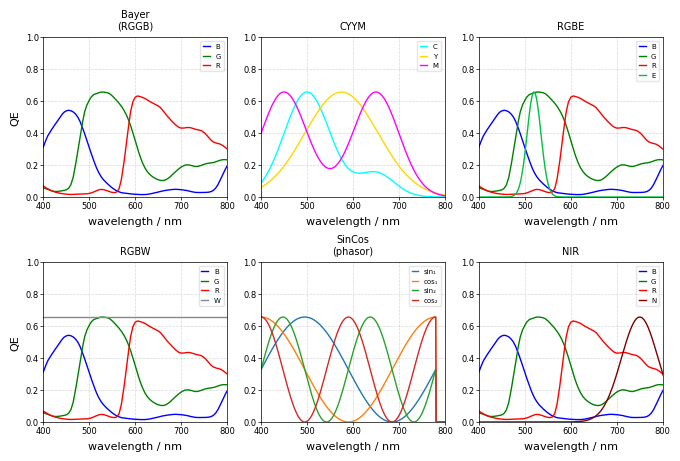

In [10]:
# ── Visualise pixel spectral QY curves ────────────────────────────────────────
_spectra_panels = [
    ("Bayer\n(RGGB)", [
        ("B", B_base, "blue"),
        ("G", G_base, "green"),
        ("R", R_base, "red"),
    ]),
    ("CYYM", [
        ("C", C_spec, "cyan"),
        ("Y", Y_spec, "gold"),
        ("M", M_spec, "magenta"),
    ]),
    ("RGBE", [
        ("B", B_base, "blue"),
        ("G", G_base, "green"),
        ("R", R_base, "red"),
        ("E", E_spec, "#00c040"),
    ]),
    ("RGBW", [
        ("B", B_base, "blue"),
        ("G", G_base, "green"),
        ("R", R_base, "red"),
        ("W", W_spec, "#888888"),
    ]),
    ("SinCos\n(phasor)", [
        ("sin₁", S1_spec, "#1f77b4"),
        ("cos₁", C1_spec, "#ff7f0e"),
        ("sin₂", S2_spec, "#2ca02c"),
        ("cos₂", C2_spec, "#d62728"),
    ]),
    ("NIR", [
        ("B", B_base, "blue"),
        ("G", G_base, "green"),
        ("R", R_base, "red"),
        ("N", N_spec, "#800000"),
    ]),
]

fs = 8
n_p = len(_spectra_panels)
fig, axs = plotter.two_column_plot(ncols=n_p//2, nrows=2, width_ratios=np.ones(n_p//2), height_ratios=np.ones(2), height=4.5)
axs = axs.ravel()
for ax, (pname, channels) in zip(axs, _spectra_panels):
    for label, spec, col in channels:
        ax = plotter.line_plot(ax, wavelength, spec, color=col, linewidth=1.0, label=label)
    ax.set_xlim([400, 800])
    ax.set_ylim([0, 1])
    ax.set_title(pname, fontsize=fs - 1)
    ax.set_xlabel("wavelength / nm", fontsize=fs)
    ax.legend(fontsize=max(fs - 3, 4), loc="upper right", framealpha=0.5,
              handlelength=1.0)
    ax.tick_params(labelsize=fs - 2)

for i in np.arange(6):
    if i == 0 or i == 3:
        axs[i].set_ylabel("QE", fontsize=fs)
    else:
        axs[i].set_ylabel("", fontsize=fs)


plt.savefig(os.path.join(save_folder_refactored, "spectral_filter_responses.svg"),
            dpi=300, format="svg")
plt.show()

/tmp/ipykernel_1926462/2673855279.py:19: UserWarning: The figure layout has changed to tight
  plt.tight_layout(pad=0.3)


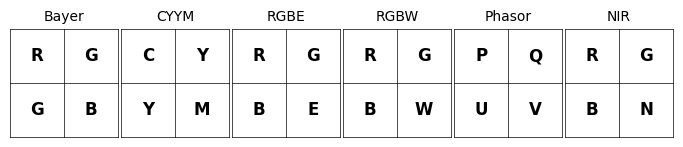

In [11]:
# ── Pixel spectral pattern visualization ──────────────────────────────────────
_spectral_mosaics = [
    ("Bayer",    mosaic_bayer),
    ("CYYM",             mosaic_cyym),
    ("RGBE",             mosaic_rgbe),
    ("RGBW",             mosaic_rgbw),
    ("Phasor", mosaic_sincos),
    ("NIR",              mosaic_nir),
]

fig, axs = plt.subplots(1, len(_spectral_mosaics), figsize=(6.69, 1.3), squeeze=True)
fs = plotter.config.font_size

for ax, (name, mosaic) in zip(axs, _spectral_mosaics):
    PlottingBase.plot_bayer_pattern(ax, pattern="".join(np.array(mosaic).ravel()),
                                    size=2, fontsize=12, dark_background=False)
    ax.set_title(name, fontsize=10)

plt.tight_layout(pad=0.3)
plt.savefig(os.path.join(save_folder_refactored, "mosaic_patterns_spectral.svg"), dpi=300, format="svg")
plt.show()

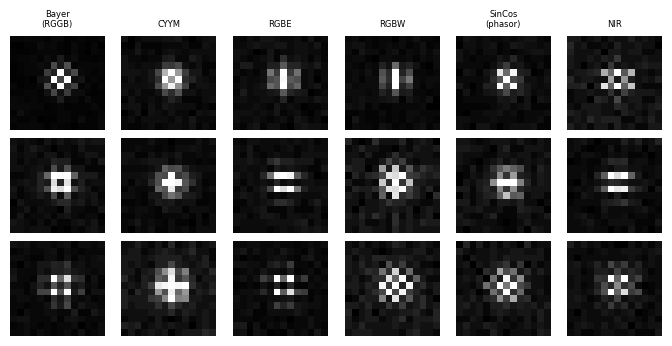

In [12]:
# ── PSF images: 3 dyes × 6 spectral patterns ──────────────────────────────────
vis_image_size = 14
vis_pixel_size = 69
vis_NA         = 1.49
vis_background = 4
vis_n_photon   = 4000
vis_dyes       = ["ATTO 488", "ATTO 565", "ATTO 647N"]
vis_filters    = []

vis_patterns = {
    "Bayer\n(RGGB)": {
        "mosaic":              mosaic_bayer,
        "pixel_QYs":           pixel_QYs_bayer,
        "pixel_order":         ["B", "G", "R"],
        "pixel_order_indices": {"B": 0, "G": 1, "R": 2},
    },
    "CYYM": {
        "mosaic":              mosaic_cyym,
        "pixel_QYs":           pixel_QYs_cyym,
        "pixel_order":         ["C", "Y", "M"],
        "pixel_order_indices": {"C": 0, "Y": 1, "M": 2},
    },
    "RGBE": {
        "mosaic":              mosaic_rgbe,
        "pixel_QYs":           pixel_QYs_rgbe,
        "pixel_order":         ["B", "G", "R", "E"],
        "pixel_order_indices": {"B": 0, "G": 1, "R": 2, "E": 3},
    },
    "RGBW": {
        "mosaic":              mosaic_rgbw,
        "pixel_QYs":           pixel_QYs_rgbw,
        "pixel_order":         ["B", "G", "R", "W"],
        "pixel_order_indices": {"B": 0, "G": 1, "R": 2, "W": 3},
    },
    "SinCos\n(phasor)": {
        "mosaic":              mosaic_sincos,
        "pixel_QYs":           pixel_QYs_sincos,
        "pixel_order":         ["P", "Q", "U", "V"],
        "pixel_order_indices": {"P": 0, "Q": 1, "U": 2, "V": 3},
    },
    "NIR": {
        "mosaic":              mosaic_nir,
        "pixel_QYs":           pixel_QYs_nir,
        "pixel_order":         ["B", "G", "R", "N"],
        "pixel_order_indices": {"B": 0, "G": 1, "R": 2, "N": 3},
    },
}

x0_vis = (vis_image_size // 2) * vis_pixel_size
y0_vis = (vis_image_size // 2) * vis_pixel_size

fs = plotter.config.font_size
n_vis_p = len(vis_patterns)
n_vis_d = len(vis_dyes)
fig, axs = plt.subplots(
    nrows=n_vis_d, ncols=n_vis_p,
    figsize=(6.69, 6.69 * n_vis_d / n_vis_p),
    squeeze=False,
)

for col, (pname, pdict) in enumerate(vis_patterns.items()):
    n_ch = len(pdict["pixel_order"])
    masks_v = M_F.get_masks(
        size_x=vis_image_size, size_y=vis_image_size,
        mosaic_unit=pdict["mosaic"],
    )
    cam_v = {
        "gain":                np.full((vis_image_size, vis_image_size), np.median(gain)),
        "offset":              np.full((vis_image_size, vis_image_size), np.median(offset)),
        "variance":            np.full((vis_image_size, vis_image_size), np.median(variance)),
        "readnoise":           float(np.median(readnoise)),
        "rqe":                 np.full((vis_image_size, vis_image_size), np.median(rqe)),
        "masks":               masks_v,
        "pixel_QYs":           pdict["pixel_QYs"],
        "pixel_order":         pdict["pixel_order"],
        "pixel_order_indices": pdict["pixel_order_indices"],
    }
    for row, dye in enumerate(vis_dyes):
        ax = axs[row, col]
        aew, dpe = S_F.get_pixel_fractions_dye_and_filters(
            dye, vis_filters, wavelength, pdict["pixel_QYs"]
        )
        n_ph_v = {dye: np.full(1, vis_n_photon)}
        x0y0_v = {dye: np.zeros([1, 2, 1])}
        x0y0_v[dye][:, :, :] = np.array([[y0_vis, x0_vis]]).T
        img, _, _ = MSF.gen_camera_image_stack(
            cam_v, wavelength,
            np.array(aew), np.array(dpe),
            n_ph_v, x0y0_v,
            background_photons=vis_background,
            background_colour=[1.0] * n_ch,   # must match number of pixel types
            smoothing_function=smoothing_function,
            NA=vis_NA, pixel_size=vis_pixel_size,
            return_normal_image=False,
        )
        plotter.image_plot(
            ax, img, colorbar=False,
            scalebarsize=200, pixelsize=vis_pixel_size, scalebarlabel="200 nm",
            scalebar_color="white", origin="lower",
        )
        if row == 0:
            ax.set_title(pname, fontsize=fs - 1)
        if col == 0:
            ax.set_ylabel(dye, fontsize=fs - 1)

plt.savefig(os.path.join(save_folder_refactored, "psf_images_spectral_patterns.svg"),
            dpi=300, format="svg")
plt.show()

In [13]:
# ── Simulation pattern registry ────────────────────────────────────────────────
sim_image_size = 14
sim_pixel_size = 69
sim_dyes       = ["ATTO 488", "ATTO 565", "ATTO 647N"]
sim_filters    = []

# name → mosaic, pixel_QYs, pixel_order, pixel_order_indices, flag
sim_spectra = {
    "Bayer": {
        "mosaic":              mosaic_bayer,
        "pixel_QYs":           pixel_QYs_bayer,
        "pixel_order":         ["B", "G", "R"],
        "pixel_order_indices": {"B": 0, "G": 1, "R": 2},
        "flag": "spec_bayer_",
    },
    "CYYM": {
        "mosaic":              mosaic_cyym,
        "pixel_QYs":           pixel_QYs_cyym,
        "pixel_order":         ["C", "Y", "M"],
        "pixel_order_indices": {"C": 0, "Y": 1, "M": 2},
        "flag": "spec_cyym_",
    },
    "RGBE": {
        "mosaic":              mosaic_rgbe,
        "pixel_QYs":           pixel_QYs_rgbe,
        "pixel_order":         ["B", "G", "R", "E"],
        "pixel_order_indices": {"B": 0, "G": 1, "R": 2, "E": 3},
        "flag": "spec_rgbe_",
    },
    "RGBW": {
        "mosaic":              mosaic_rgbw,
        "pixel_QYs":           pixel_QYs_rgbw,
        "pixel_order":         ["B", "G", "R", "W"],
        "pixel_order_indices": {"B": 0, "G": 1, "R": 2, "W": 3},
        "flag": "spec_rgbw_",
    },
    "SinCos": {
        "mosaic":              mosaic_sincos,
        "pixel_QYs":           pixel_QYs_sincos,
        "pixel_order":         ["P", "Q", "U", "V"],
        "pixel_order_indices": {"P": 0, "Q": 1, "U": 2, "V": 3},
        "flag": "spec_sincos_",
    },
    "NIR": {
        "mosaic":              mosaic_nir,
        "pixel_QYs":           pixel_QYs_nir,
        "pixel_order":         ["B", "G", "R", "N"],
        "pixel_order_indices": {"B": 0, "G": 1, "R": 2, "N": 3},
        "flag": "spec_nir_",
    },
}

print("Spectral pattern registry:")
for _name, _pd in sim_spectra.items():
    print(f"  {_name:8s}  {len(_pd['pixel_order'])} pixel types  "
          f"order={_pd['pixel_order']}  flag={_pd['flag']!r}")
print(f"\nDyes: {sim_dyes}")
print(f"Photon levels: {len(n_photon_space_spec)}  "
      f"({n_photon_space_spec[0]:.0f}–{n_photon_space_spec[-1]:.0f})")
print(f"Save folder: {save_folder_refactored}")

Spectral pattern registry:
  Bayer     3 pixel types  order=['B', 'G', 'R']  flag='spec_bayer_'
  CYYM      3 pixel types  order=['C', 'Y', 'M']  flag='spec_cyym_'
  RGBE      4 pixel types  order=['B', 'G', 'R', 'E']  flag='spec_rgbe_'
  RGBW      4 pixel types  order=['B', 'G', 'R', 'W']  flag='spec_rgbw_'
  SinCos    4 pixel types  order=['P', 'Q', 'U', 'V']  flag='spec_sincos_'
  NIR       4 pixel types  order=['B', 'G', 'R', 'N']  flag='spec_nir_'

Dyes: ['ATTO 488', 'ATTO 565', 'ATTO 647N']
Photon levels: 200  (500–50000)
Save folder: /scratch/sycamore-asap/ASAP_Members_Other_Imaging_Data/JSB/Simulation/20260629_SpectralFilterPatterns


In [ ]:
# ── Run simulations for all spectral patterns × dyes ──────────────────────────
import time as _time

n_total_spec = len(sim_spectra) * len(sim_dyes)
i_spec  = 0
t0_spec = _time.time()

for pattern_name, pdict in sim_spectra.items():
    n_ch      = len(pdict["pixel_order"])
    masks_sim = M_F.get_masks(
        size_x=sim_image_size, size_y=sim_image_size,
        mosaic_unit=pdict["mosaic"],
    )
    cam_sim = {
        "gain":                np.full((sim_image_size, sim_image_size), np.median(gain)),
        "offset":              np.full((sim_image_size, sim_image_size), np.median(offset)),
        "variance":            np.full((sim_image_size, sim_image_size), np.median(variance)),
        "readnoise":           float(np.median(readnoise)),
        "rqe":                 np.full((sim_image_size, sim_image_size), np.median(rqe)),
        "masks":               masks_sim,
        "pixel_QYs":           pdict["pixel_QYs"],
        "pixel_order":         pdict["pixel_order"],
        "pixel_order_indices": pdict["pixel_order_indices"],
        "mosaic_unit":          pdict["mosaic"],
    }
    # background_colour length must match the number of pixel types
    config_pat = SimulationConfig(
        n_bootstrap=config_spec.n_bootstrap,
        background_photons=config_spec.background_photons,
        background_colour=[1.0] * n_ch,
        NA=config_spec.NA,
        pixel_size=config_spec.pixel_size,
        save_raw_results=config_spec.save_raw_results,
        subtractx0y0=config_spec.subtractx0y0,
        saverawimages=config_spec.saverawimages,
        verbose=config_spec.verbose,
        use_stochastic_photons=config_spec.use_stochastic_photons,
        n_unit_cells=config_spec.n_unit_cells,
    )
    for dye in sim_dyes:
        i_spec += 1
        print(f"[{i_spec:2d}/{n_total_spec}]  {pattern_name:8s}  {dye}", end="  ")
        try:
            MSF.test_simulation_method(
                dye=dye,
                filters=sim_filters,
                wavelength=wavelength,
                camera_parameters=cam_sim,
                save_folder=save_folder_refactored,
                n_photon_space=n_photon_space_spec,
                smoothing_function=smoothing_function,
                strategy=FittingStrategy.STANDARD,
                starting_flag=pdict["flag"],
                config=config_pat,
                overwrite=True,
            )
            elapsed = (_time.time() - t0_spec) / 60
            rate    = i_spec / elapsed if elapsed > 0 else 0
            eta     = (n_total_spec - i_spec) / rate if rate > 0 else 0
            print(f"done  ({elapsed:.1f} min, ETA {eta:.1f} min)")
        except Exception as e:
            print(f"FAILED: {e}")

print(f"\nAll spectral pattern simulations complete in "
      f"{(_time.time() - t0_spec) / 60:.1f} min.")

In [ ]:
# ── Load results → build Spectral_Patterns_XR ─────────────────────────────────
# Dims: [pattern, dye, n_photons, metric]   metrics = ["sigma_xy", "sigma_colour"]
_all_files_spec = os.listdir(save_folder_refactored)
_params_spec    = ["sigma_xy", "sigma_colour"]
_spec_names     = list(sim_spectra.keys())

Spectral_Patterns_XR = xr.DataArray(
    data=np.full(
        [len(_spec_names), len(sim_dyes), len(n_photon_space_spec), len(_params_spec)],
        np.nan,
    ),
    coords={
        "pattern":   _spec_names,
        "dye":       sim_dyes,
        "n_photons": n_photon_space_spec,
        "metric":    _params_spec,
    },
    dims=["pattern", "dye", "n_photons", "metric"],
)

for i_p, (pattern_name, pdict) in enumerate(sim_spectra.items()):
    flag        = pdict["flag"]
    pixel_order = pdict["pixel_order"]
    n_ch        = len(pixel_order)
    a_cols      = [f"A_{lbl}" for lbl in pixel_order]

    for i_d, dye in enumerate(sim_dyes):
        dye_str   = dye.replace("/", "-")
        dye_files = [
            os.path.join(save_folder_refactored, f)
            for f in _all_files_spec
            if f.startswith(flag) and dye_str in f
        ]
        raw_file = [f for f in dye_files if "rawresults" in f]
        gt_file  = [f for f in dye_files if "groundtruth" in f]
        ip_file  = [f for f in dye_files if "input_parameters" in f]

        if not raw_file or not gt_file or not ip_file:
            print(f"Missing files: {pattern_name} / {dye}")
            continue
        gt    = pd.read_csv(gt_file[0])
        gt_px = np.vstack([gt["x0"].to_numpy() / sim_pixel_size,
                           gt["y0"].to_numpy() / sim_pixel_size]).T

        ip_row      = pd.read_csv(ip_file[0]).to_numpy()[0]
        colour_raw  = ip_row[-n_ch:]
        colour_true = np.expand_dims(colour_raw / colour_raw.sum(), 0)

        df_raw = pd.read_hdf(raw_file[0])

        for k in range(len(n_photon_space_spec)):
            sub  = df_raw[df_raw["photon_level"] == k]
            filt = ~(
                (sub["xc"] < 0) | (sub["yc"] < 0) |
                (sub["s_x"] < 0) | (sub["s_y"] < 0) |
                (sub["xc"] > config_spec.n_unit_cells * pdict["mosaic"].shape[0]) | (sub["yc"] > config_spec.n_unit_cells * pdict["mosaic"].shape[1])
            )
            if filt.sum() < 5:
                continue
            ex = sub["xc"].to_numpy()[filt] - gt_px[filt, 0]
            ey = sub["yc"].to_numpy()[filt] - gt_px[filt, 1]
            Spectral_Patterns_XR[i_p, i_d, k, 0] = (
                np.sqrt((np.nanstd(ex) ** 2 + np.nanstd(ey) ** 2) / 2) * sim_pixel_size
            )
            colour = np.vstack([sub[c].to_numpy()[filt] for c in a_cols]).T
            Spectral_Patterns_XR[i_p, i_d, k, 1] = float(
                np.nanstd(cdist(colour, colour_true))
            )

Spectral_Patterns_XR.to_netcdf(
    os.path.join(save_folder_refactored, "Spectral_Patterns_XR.nc")
)
print(f"Saved  shape={Spectral_Patterns_XR.shape}  "
      f"dims={list(Spectral_Patterns_XR.dims)}")
n_valid = int(np.sum(~np.isnan(Spectral_Patterns_XR.sel(metric="sigma_xy").values)))
print(f"{n_valid} / {Spectral_Patterns_XR.sel(metric='sigma_xy').size} grid cells filled")

In [ ]:
# ── Comparison: σ_xy and σ_colour vs N_photons, all spectral patterns ─────────
Spectral_Patterns_XR = xr.load_dataarray(
    os.path.join(save_folder_refactored, "Spectral_Patterns_XR.nc")
)

_spec_styles = {
    "Bayer":  dict(color="black",   linewidth=1.5, linestyle="-"),
    "CYYM":   dict(color="#e6194b", linewidth=1.2, linestyle="-"),
    "RGBE":   dict(color="#3cb44b", linewidth=1.2, linestyle="-"),
    "RGBW":   dict(color="#4363d8", linewidth=1.2, linestyle="-"),
    "SinCos": dict(color="#f58231", linewidth=1.2, linestyle="--"),
    "NIR":    dict(color="#911eb4", linewidth=1.2, linestyle="-"),
}
_dyes = ['ATTO 488', 'ATTO 565', 'ATTO 647N']

fig, axs = plotter.two_column_plot(ncols=3, nrows=2, width_ratios=[1,1,1], height_ratios=[1,1])
fs = 8

for ax, metric, ylabel in [
    (axs[0, :], "sigma_xy",     r"$\sigma_{xy}$ / nm"),
    (axs[1, :], "sigma_colour", r"$\sigma_{\rm colour}$"),
]:
    for pattern_name, style in _spec_styles.items():
            for d_num, dye in enumerate(_dyes):
                y = (Spectral_Patterns_XR.sel(pattern=pattern_name, metric=metric, dye=dye))
                ax[d_num] = plotter.line_plot(ax[d_num], n_photon_space_spec, y,
                    label=pattern_name.replace("_", " "), **style)

                ax[d_num].set_xscale("log")
                ax[d_num].set_yscale("log")
                ax[d_num].set_xlabel(r"$N_{\rm photons}$", fontsize=fs)
                ax[d_num].set_ylabel(ylabel, fontsize=fs)
                ax[d_num].set_xlim([n_photon_space_spec[0], n_photon_space_spec[-1]])
                ax[d_num].tick_params(labelsize=fs-1)
                ax[d_num].legend(loc="best", fontsize=fs - 2, framealpha=0.7)

plt.savefig(
    os.path.join(save_folder_refactored, "spectral_patterns_precision_comparison.svg"),
    dpi=300, format="svg",
)
plt.show()